# Multi-Agent Path Finding (MAPF) usando PuLP

## Problema de planificación de rutas para múltiples robots

En este proyecto buscamos determinar las rutas de varios robots que deben
desplazarse desde un nodo inicial hasta un nodo destino dentro de una red.

El objetivo es encontrar rutas factibles para todos los robots evitando
colisiones y buscando que todos lleguen a sus destinos en el menor tiempo
posible.

El problema se formula como un modelo de Programación Lineal Entera Mixta
(MILP) y se resuelve utilizando PuLP.

## 1. Enunciado del problema

Tenemos una cuadrícula en la que se desplazan varios robots.

Cada robot $i$ tiene:

- una posición inicial $s_i$;
- una posición objetivo $g_i$.

En cada instante de tiempo, un robot puede:

- desplazarse a una celda vecina, o
- permanecer en la misma celda.

Debemos encontrar una ruta para cada robot de manera que:

1. Cada robot comience en su posición inicial.
2. Cada robot llegue a su destino.
3. Cada robot ocupe exactamente una posición en cada instante.
4. Dos robots no puedan ocupar el mismo nodo al mismo tiempo.
5. Dos robots no puedan intercambiar posiciones atravesando la misma
   arista en sentidos contrarios simultáneamente.
6. Las rutas sean continuas.
7. Se minimice el tiempo máximo de llegada de los robots.

Este problema se conoce como **Multi-Agent Path Finding (MAPF)**.

In [54]:
!pip install pulp -q

In [55]:
import pulp
import matplotlib.pyplot as plt

## 2. Representación del espacio

Representamos el espacio mediante un grafo dirigido:

$$
G=(V,E)
$$

donde:

- $V$ es el conjunto de nodos o posiciones.
- $E$ es el conjunto de movimientos permitidos entre nodos.

En nuestro ejemplo utilizaremos una cuadrícula de $5\times5$.

Cada robot puede moverse:

- arriba;
- abajo;
- izquierda;
- derecha;

o puede permanecer en el mismo nodo mediante un movimiento de espera.

El movimiento de espera se representa mediante una arista:

$$
(v,v)
$$

In [56]:
# Dimensiones de la cuadrícula
FILAS = 5
COLUMNAS = 5

# Conjunto de nodos
V = [
    (i, j)
    for i in range(FILAS)
    for j in range(COLUMNAS)
]

# Conjunto de aristas dirigidas
E = []

for i, j in V:

    # Movimiento de espera
    E.append(((i, j), (i, j)))

    # Arriba
    if i > 0:
        E.append(((i, j), (i - 1, j)))

    # Abajo
    if i < FILAS - 1:
        E.append(((i, j), (i + 1, j)))

    # Izquierda
    if j > 0:
        E.append(((i, j), (i, j - 1)))

    # Derecha
    if j < COLUMNAS - 1:
        E.append(((i, j), (i, j + 1)))


print("Número de nodos:", len(V))
print("Número de movimientos posibles:", len(E))

Número de nodos: 25
Número de movimientos posibles: 105


## 3. Visualización de la red

Antes de crear el modelo de optimización, visualizamos la cuadrícula
que representa el espacio donde se moverán los robots.

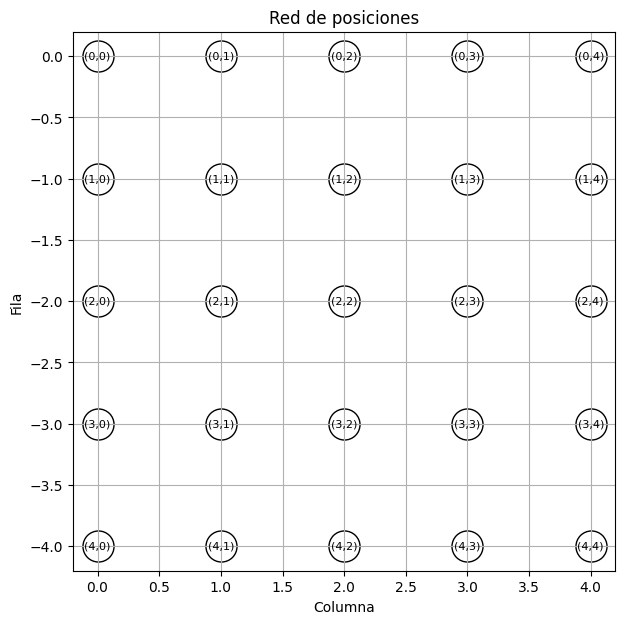

In [57]:
plt.figure(figsize=(7, 7))

for i, j in V:

    plt.scatter(
        j,
        -i,
        s=500,
        facecolors="white",
        edgecolors="black"
    )

    plt.text(
        j,
        -i,
        f"({i},{j})",
        ha="center",
        va="center",
        fontsize=8
    )

plt.title("Red de posiciones")
plt.xlabel("Columna")
plt.ylabel("Fila")
plt.grid(True)

plt.show()

## 4. Definición de los robots

Definimos un conjunto de robots $R$.

Cada robot tiene una posición inicial $s_i$ y una posición objetivo $g_i$.

Para nuestro ejemplo tendremos cuatro robots:

| Robot | Inicio | Destino |
|------|--------|---------|
| 0 | (0,0) | (4,4) |
| 1 | (0,4) | (4,0) |
| 2 | (4,0) | (0,4) |
| 3 | (4,4) | (0,0) |

Los robots tendrán que encontrar rutas simultáneamente evitando
interferirse entre ellos.

In [58]:
robots = {
    0: {"start": (0, 0), "goal": (4, 4)},
    1: {"start": (0, 4), "goal": (4, 0)},
    2: {"start": (4, 0), "goal": (0, 4)},
    3: {"start": (4, 4), "goal": (0, 0)}
}

R = list(robots.keys())

print("Robots:", R)

for i in R:
    print(
        f"Robot {i}: "
        f"{robots[i]['start']} -> {robots[i]['goal']}"
    )

Robots: [0, 1, 2, 3]
Robot 0: (0, 0) -> (4, 4)
Robot 1: (0, 4) -> (4, 0)
Robot 2: (4, 0) -> (0, 4)
Robot 3: (4, 4) -> (0, 0)


## 5. Horizonte temporal

Los robots se moverán durante un conjunto finito de instantes:

$$
K=\{1,2,\ldots,T\}
$$

donde $T$ representa el número máximo de pasos permitidos.

Para este ejemplo utilizaremos:

$$
T=20
$$

El horizonte debe ser suficientemente grande para que exista una solución.

In [59]:
T = 20

K = range(1, T + 1)

print("Horizonte temporal:", T)

Horizonte temporal: 20


## 6. Variables de decisión

Utilizamos dos tipos de variables binarias.

### Variable de posición

Definimos:

$$
x^i_{v,k}\in\{0,1\}
$$

donde:

$$
x^i_{v,k}=1
$$

si el robot $i$ está ubicado en el nodo $v$ en el instante $k$.

De lo contrario:

$$
x^i_{v,k}=0
$$

---

### Variable de movimiento

Definimos:

$$
\rho^i_{a,b,k}\in\{0,1\}
$$

donde:

$$
\rho^i_{a,b,k}=1
$$

si el robot $i$ se mueve desde el nodo $a$ hasta el nodo $b$
durante el instante $k$.

Estas dos variables permiten relacionar la posición de un robot
con sus movimientos.

In [60]:
# Crear el modelo
modelo = pulp.LpProblem(
    "MAPF",
    pulp.LpMinimize
)

# Variable x:
# x[i][v][k] = 1 si el robot i está en v en el instante k
x = pulp.LpVariable.dicts(
    "x",
    (R, V, range(T + 1)),
    cat=pulp.LpBinary
)

# Variable rho:
# rho[i][e][k] = 1 si el robot i utiliza la arista e en el instante k
rho = pulp.LpVariable.dicts(
    "rho",
    (R, range(len(E)), K),
    cat=pulp.LpBinary
)

print("Variables creadas correctamente.")

Variables creadas correctamente.


## 7. Restricción: una única posición por robot

Cada robot debe ocupar exactamente un nodo en cada instante:

$$
\sum_{v\in V}x^i_{v,k}=1
\qquad
\forall i\in R,\ \forall k
$$

Esta restricción evita que un robot pueda aparecer simultáneamente
en dos posiciones diferentes.

En palabras:

> En cada instante, cada robot debe estar exactamente en una posición.

In [61]:
for i in R:

    for k in range(T + 1):

        modelo += (
            pulp.lpSum(
                x[i][v][k]
                for v in V
            ) == 1
        ), f"Una_posicion_{i}_{k}"

## 8. Restricción: posición inicial

Cada robot debe comenzar en su nodo de origen:

$$
x^i_{s_i,0}=1
\qquad
\forall i\in R
$$

Esto fija la posición inicial de cada robot.

In [62]:
for i in R:

    origen = robots[i]["start"]

    modelo += (
        x[i][origen][0] == 1
    ), f"Inicio_robot_{i}"

## 9. Restricción: posición final

Al finalizar el horizonte temporal, cada robot debe encontrarse
en su nodo objetivo:

$$
x^i_{g_i,T}=1
\qquad
\forall i\in R
$$

De esta manera garantizamos que todos los robots lleguen a sus destinos.

In [63]:
for i in R:

    destino = robots[i]["goal"]

    modelo += (
        x[i][destino][T] == 1
    ), f"Destino_robot_{i}"

## 10. Conservación de movimiento

Ahora debemos conectar la posición del robot con sus movimientos.

### Salida

Si el robot está en $a$ en el instante $k-1$, debe utilizar exactamente
un movimiento que salga de $a$:

$$
\sum_{b:(a,b)\in E}
\rho^i_{a,b,k}
=
x^i_{a,k-1}
$$

### Llegada

De forma equivalente, si el robot está en $b$ en el instante $k$,
debe existir exactamente un movimiento que llegue a $b$:

$$
\sum_{a:(a,b)\in E}
\rho^i_{a,b,k}
=
x^i_{b,k}
$$

Estas restricciones conectan:

$$
\boxed{
\text{posición anterior}
\rightarrow
\text{movimiento}
\rightarrow
\text{posición siguiente}
}
$$

Por lo tanto, las rutas obtenidas por el modelo son continuas.

In [64]:
for i in R:

    for k in K:

        # ---------------------------------
        # Restricción de salida
        # ---------------------------------

        for a in V:

            salidas = [
                e_idx
                for e_idx, (origen, destino) in enumerate(E)
                if origen == a
            ]

            modelo += (
                pulp.lpSum(
                    rho[i][e_idx][k]
                    for e_idx in salidas
                )
                == x[i][a][k - 1]
            ), f"Salida_{i}_{a}_{k}"


        # ---------------------------------
        # Restricción de llegada
        # ---------------------------------

        for b in V:

            entradas = [
                e_idx
                for e_idx, (origen, destino) in enumerate(E)
                if destino == b
            ]

            modelo += (
                pulp.lpSum(
                    rho[i][e_idx][k]
                    for e_idx in entradas
                )
                == x[i][b][k]
            ), f"Entrada_{i}_{b}_{k}"

## 11. Restricción de no colisión

Queremos evitar que dos robots ocupen el mismo nodo al mismo tiempo.

La restricción es:

$$
\sum_{i\in R}x^i_{v,k}\leq1
\qquad
\forall v\in V,\ \forall k
$$

Esta expresión significa:

> En cada nodo y en cada instante puede existir como máximo un robot.

Esta es la principal restricción que evita las colisiones entre robots
dentro de los nodos.

In [65]:
for v in V:

    for k in range(T + 1):

        modelo += (
            pulp.lpSum(
                x[i][v][k]
                for i in R
            )
            <= 1
        ), f"No_colision_{v}_{k}"

## 12. Restricción de Swapping

La restricción de capacidad evita que dos robots estén en el mismo nodo,
pero todavía puede existir otro tipo de conflicto.

Por ejemplo:

$$
A\rightarrow B
$$

y simultáneamente:

$$
B\rightarrow A
$$

Los dos robots estarían intercambiando sus posiciones.

Para evitar esto utilizamos:

$$
\rho^i_{a,b,k}
+
\rho^j_{b,a,k}
\leq1
$$

para dos robots diferentes $i$ y $j$.

Esta restricción evita que dos robots atraviesen simultáneamente
la misma conexión en sentidos opuestos.

In [66]:
for a, b in E:

    # No necesitamos analizar movimientos de espera
    if a == b:
        continue

    # Si no existe la arista contraria, no hay swapping
    if (b, a) not in E:
        continue

    e_ab = E.index((a, b))
    e_ba = E.index((b, a))

    for k in K:

        for i in R:

            for j in R:

                if i < j:

                    modelo += (
                        rho[i][e_ab][k]
                        +
                        rho[j][e_ba][k]
                        <= 1
                    ), f"Swap_{i}_{j}_{a}_{b}_{k}"

## 13. Makespan

Queremos minimizar el tiempo máximo que tarda cualquiera de los robots
en llegar a su destino.

Definimos la variable:

$$
\beta\geq0
$$

que representa el tiempo máximo de llegada.

El objetivo será:

$$
\boxed{\min \beta}
$$

Para identificar el instante de llegada de cada robot definimos además:

$$
y^i_k\in\{0,1\}
$$

donde $y^i_k=1$ significa que el robot $i$ considera el instante $k$
como su instante de llegada.

Imponemos:

$$
\sum_{k=0}^{T}y^i_k=1
\qquad \forall i
$$

y:

$$
y^i_k\leq x^i_{g_i,k}
$$

por lo que el instante de llegada seleccionado debe corresponder
a un momento en el que el robot se encuentra en su destino.

Finalmente:

$$
\beta\geq
\sum_{k=0}^{T}k\,y^i_k
\qquad\forall i
$$

Al minimizar $\beta$, el modelo busca minimizar el mayor tiempo de llegada.

In [67]:
# Variable y:
# y[i][k] = 1 si k es el instante de llegada seleccionado del robot i
y = pulp.LpVariable.dicts(
    "y",
    (R, range(T + 1)),
    cat=pulp.LpBinary
)

# Variable beta
beta = pulp.LpVariable(
    "Beta",
    lowBound=0,
    cat=pulp.LpInteger
)


# Cada robot tiene exactamente un instante de llegada
for i in R:

    modelo += (
        pulp.lpSum(
            y[i][k]
            for k in range(T + 1)
        ) == 1
    ), f"Un_tiempo_llegada_{i}"


# El instante seleccionado debe ser un instante
# en el que el robot está en su destino
for i in R:

    destino = robots[i]["goal"]

    for k in range(T + 1):

        modelo += (
            y[i][k]
            <= x[i][destino][k]
        ), f"Llegada_real_{i}_{k}"


# Beta debe ser mayor o igual al tiempo de llegada
# de cada robot
for i in R:

    modelo += (
        pulp.lpSum(
            k * y[i][k]
            for k in range(T + 1)
        )
        <= beta
    ), f"Makespan_{i}"


# Función objetivo
modelo += beta

## 14. Resolución del problema

Una vez definidas:

- las variables;
- la función objetivo;
- las restricciones;

podemos utilizar el solver CBC incluido con PuLP.

El solver buscará una solución factible y, posteriormente,
intentará encontrar la solución que minimice el Makespan $\beta$.

In [68]:
solver = pulp.PULP_CBC_CMD(msg=True)

modelo.solve(solver)

print("===================================")
print("RESULTADO")
print("===================================")

print("Estado:", pulp.LpStatus[modelo.status])

if pulp.LpStatus[modelo.status] == "Optimal":

    print("Makespan óptimo:", pulp.value(beta))

else:

    print("No se encontró una solución óptima.")

RESULTADO
Estado: Optimal
Makespan óptimo: 8.0


In [69]:
print("Número de variables:", len(modelo.variables()))
print("Número de restricciones:", len(modelo.constraints))
print("Valor de la función objetivo:", pulp.value(modelo.objective))

Número de variables: 10585
Número de restricciones: 14309
Valor de la función objetivo: 8.0


## 15. Recuperación de las rutas

Después de resolver el modelo, debemos convertir los valores de las
variables de decisión en rutas que podamos interpretar.

Para cada robot observaremos su posición en cada instante:

$$
x^i_{v,k}=1
$$

El nodo correspondiente será la posición del robot en ese instante.

In [70]:
trayectorias = {}

if pulp.LpStatus[modelo.status] == "Optimal":

    for i in R:

        trayectoria = []

        for k in range(T + 1):

            posicion = None

            for v in V:

                valor = pulp.value(x[i][v][k])

                if valor is not None and valor > 0.5:
                    posicion = v
                    break

            trayectoria.append(posicion)

        trayectorias[i] = trayectoria


        print(f"\nRobot {i}")
        print("-" * 30)

        for k, posicion in enumerate(trayectoria):
            print(f"t={k}: {posicion}")


Robot 0
------------------------------
t=0: (0, 0)
t=1: (1, 0)
t=2: (2, 0)
t=3: (3, 0)
t=4: (4, 0)
t=5: (4, 1)
t=6: (4, 2)
t=7: (4, 3)
t=8: (4, 4)
t=9: (4, 3)
t=10: (4, 4)
t=11: (4, 4)
t=12: (4, 4)
t=13: (3, 4)
t=14: (3, 3)
t=15: (3, 2)
t=16: (2, 2)
t=17: (2, 3)
t=18: (3, 3)
t=19: (4, 3)
t=20: (4, 4)

Robot 1
------------------------------
t=0: (0, 4)
t=1: (0, 3)
t=2: (0, 2)
t=3: (0, 1)
t=4: (1, 1)
t=5: (2, 1)
t=6: (3, 1)
t=7: (4, 1)
t=8: (4, 0)
t=9: (4, 0)
t=10: (4, 0)
t=11: (4, 1)
t=12: (4, 2)
t=13: (3, 2)
t=14: (2, 2)
t=15: (1, 2)
t=16: (1, 1)
t=17: (1, 0)
t=18: (2, 0)
t=19: (3, 0)
t=20: (4, 0)

Robot 2
------------------------------
t=0: (4, 0)
t=1: (4, 1)
t=2: (4, 2)
t=3: (4, 3)
t=4: (3, 3)
t=5: (2, 3)
t=6: (1, 3)
t=7: (1, 4)
t=8: (0, 4)
t=9: (0, 4)
t=10: (0, 4)
t=11: (1, 4)
t=12: (2, 4)
t=13: (2, 4)
t=14: (3, 4)
t=15: (3, 4)
t=16: (4, 4)
t=17: (3, 4)
t=18: (2, 4)
t=19: (1, 4)
t=20: (0, 4)

Robot 3
------------------------------
t=0: (4, 4)
t=1: (3, 4)
t=2: (2, 4)
t=3: (1, 4)
t=4

In [71]:
print("\nRUTAS DE LOS ROBOTS")
print("=" * 50)

for i in R:

    destino = robots[i]["goal"]

    trayectoria = trayectorias[i]

    # Encontrar primera llegada al destino
    tiempo_llegada = None

    for k, posicion in enumerate(trayectoria):

        if posicion == destino:

            tiempo_llegada = k
            break

    print(f"\nRobot {i}")
    print(f"Inicio : {robots[i]['start']}")
    print(f"Destino: {destino}")
    print(f"Llegada: t={tiempo_llegada}")

    print("Ruta:")

    for k in range(tiempo_llegada + 1):

        print(
            f"  t={k}: {trayectoria[k]}"
        )


RUTAS DE LOS ROBOTS

Robot 0
Inicio : (0, 0)
Destino: (4, 4)
Llegada: t=8
Ruta:
  t=0: (0, 0)
  t=1: (1, 0)
  t=2: (2, 0)
  t=3: (3, 0)
  t=4: (4, 0)
  t=5: (4, 1)
  t=6: (4, 2)
  t=7: (4, 3)
  t=8: (4, 4)

Robot 1
Inicio : (0, 4)
Destino: (4, 0)
Llegada: t=8
Ruta:
  t=0: (0, 4)
  t=1: (0, 3)
  t=2: (0, 2)
  t=3: (0, 1)
  t=4: (1, 1)
  t=5: (2, 1)
  t=6: (3, 1)
  t=7: (4, 1)
  t=8: (4, 0)

Robot 2
Inicio : (4, 0)
Destino: (0, 4)
Llegada: t=8
Ruta:
  t=0: (4, 0)
  t=1: (4, 1)
  t=2: (4, 2)
  t=3: (4, 3)
  t=4: (3, 3)
  t=5: (2, 3)
  t=6: (1, 3)
  t=7: (1, 4)
  t=8: (0, 4)

Robot 3
Inicio : (4, 4)
Destino: (0, 0)
Llegada: t=8
Ruta:
  t=0: (4, 4)
  t=1: (3, 4)
  t=2: (2, 4)
  t=3: (1, 4)
  t=4: (1, 3)
  t=5: (1, 2)
  t=6: (1, 1)
  t=7: (1, 0)
  t=8: (0, 0)


## 16. Verificación de colisiones

Aunque el modelo contiene restricciones de no colisión,
podemos verificar posteriormente la solución obtenida.

Para cada instante debemos comprobar que ningún nodo tenga más
de un robot.

Es decir:

$$
\sum_i x^i_{v,k}\leq1
$$

debe cumplirse para todos los nodos y tiempos.

In [72]:
colisiones = []

for k in range(T + 1):

    ocupacion = {}

    for i in R:

        posicion = trayectorias[i][k]

        if posicion not in ocupacion:
            ocupacion[posicion] = []

        ocupacion[posicion].append(i)

    for posicion, robots_en_nodo in ocupacion.items():

        if len(robots_en_nodo) > 1:

            colisiones.append(
                (k, posicion, robots_en_nodo)
            )


if len(colisiones) == 0:

    print("✓ No existen colisiones entre robots.")

else:

    print("✗ Se encontraron colisiones:")

    for conflicto in colisiones:
        print(conflicto)

✓ No existen colisiones entre robots.


## 17. Verificación de Swapping

También verificamos que no exista un intercambio de posiciones.

No debe ocurrir que en el mismo instante:

$$
i:A\rightarrow B
$$

y:

$$
j:B\rightarrow A
$$

para dos robots diferentes.

In [73]:
swaps = []

for k in range(T):

    for i in R:

        a = trayectorias[i][k]
        b = trayectorias[i][k + 1]

        for j in R:

            if i >= j:
                continue

            c = trayectorias[j][k]
            d = trayectorias[j][k + 1]

            if a == d and b == c and a != b:

                swaps.append(
                    (k, i, j, a, b)
                )


if len(swaps) == 0:

    print("✓ No existen intercambios de posiciones (swapping).")

else:

    print("✗ Se encontraron casos de swapping:")

    for conflicto in swaps:
        print(conflicto)

✓ No existen intercambios de posiciones (swapping).


## 18. Visualización de la solución

Finalmente representamos gráficamente las rutas encontradas.

Cada línea representa la trayectoria de un robot a través de los
diferentes instantes de tiempo.

Los cuadrados representan las posiciones iniciales y las estrellas
representan los destinos.

La trayectoria se construye siguiendo el orden temporal:

$$
t=0\rightarrow t=1\rightarrow t=2\rightarrow\cdots
$$

Por lo tanto, las líneas representan rutas reales y continuas,
no simplemente las aristas seleccionadas sin orden.

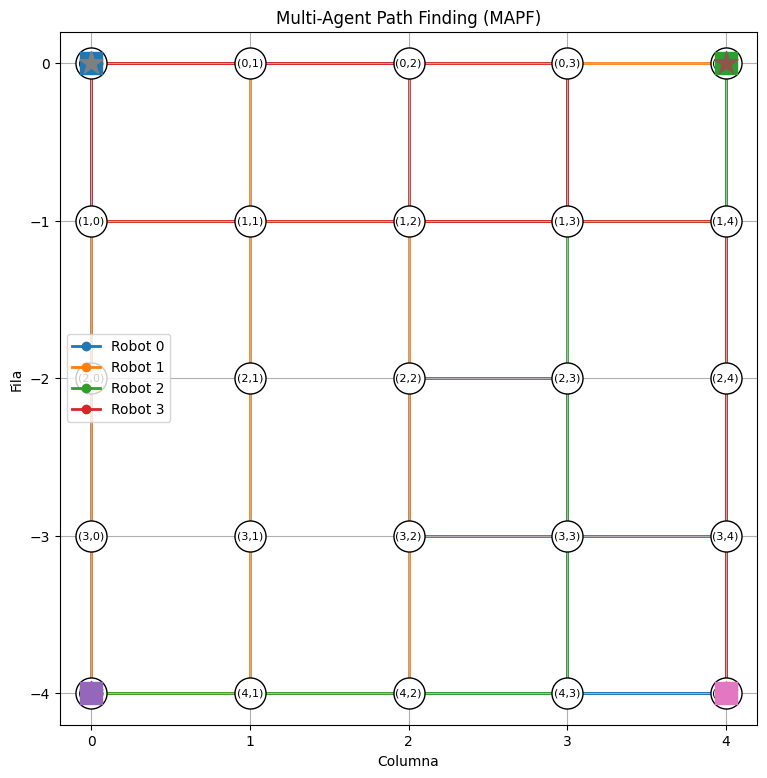

In [74]:
plt.figure(figsize=(9, 9))

# Dibujar nodos
for i, j in V:

    plt.scatter(
        j,
        -i,
        s=500,
        facecolors="white",
        edgecolors="black",
        zorder=2
    )

    plt.text(
        j,
        -i,
        f"({i},{j})",
        ha="center",
        va="center",
        fontsize=8,
        zorder=3
    )


# Dibujar rutas
for i in R:

    trayectoria = trayectorias[i]

    # Convertir nodos a coordenadas
    xs = [
        posicion[1]
        for posicion in trayectoria
    ]

    ys = [
        -posicion[0]
        for posicion in trayectoria
    ]

    # Dibujar trayectoria completa
    plt.plot(
        xs,
        ys,
        marker="o",
        linewidth=2,
        label=f"Robot {i}",
        zorder=1
    )

    # Posición inicial
    inicio = robots[i]["start"]

    plt.scatter(
        inicio[1],
        -inicio[0],
        s=250,
        marker="s",
        zorder=4
    )

    # Destino
    destino = robots[i]["goal"]

    plt.scatter(
        destino[1],
        -destino[0],
        s=300,
        marker="*",
        zorder=4
    )


plt.title("Multi-Agent Path Finding (MAPF)")
plt.xlabel("Columna")
plt.ylabel("Fila")

plt.xticks(range(COLUMNAS))
plt.yticks(range(-(FILAS - 1), 1))

plt.grid(True)
plt.legend()

plt.show()

In [75]:
for t in range(T + 1):

    print(f"==================== t = {t} ====================")

    for i in R:

        posicion = trayectorias[i][t]

        print(
            f"Robot {i}: {posicion}"
        )

    print()

==================== t = 0 ====================
Robot 0: (0, 0)
Robot 1: (0, 4)
Robot 2: (4, 0)
Robot 3: (4, 4)

==================== t = 1 ====================
Robot 0: (1, 0)
Robot 1: (0, 3)
Robot 2: (4, 1)
Robot 3: (3, 4)

==================== t = 2 ====================
Robot 0: (2, 0)
Robot 1: (0, 2)
Robot 2: (4, 2)
Robot 3: (2, 4)

==================== t = 3 ====================
Robot 0: (3, 0)
Robot 1: (0, 1)
Robot 2: (4, 3)
Robot 3: (1, 4)

==================== t = 4 ====================
Robot 0: (4, 0)
Robot 1: (1, 1)
Robot 2: (3, 3)
Robot 3: (1, 3)

==================== t = 5 ====================
Robot 0: (4, 1)
Robot 1: (2, 1)
Robot 2: (2, 3)
Robot 3: (1, 2)

==================== t = 6 ====================
Robot 0: (4, 2)
Robot 1: (3, 1)
Robot 2: (1, 3)
Robot 3: (1, 1)

==================== t = 7 ====================
Robot 0: (4, 3)
Robot 1: (4, 1)
Robot 2: (1, 4)
Robot 3: (1, 0)

==================== t = 8 ====================
Robot 0: (4, 4)
Robot 1: (4, 0)
Robot 2: (0, 4)


## 20. Animación de los robots

Para visualizar la solución de manera dinámica, construiremos una
animación en la que cada instante de tiempo corresponde a un cuadro.

La animación representa:

$$
t=0\rightarrow t=1\rightarrow t=2\rightarrow\cdots\rightarrow T
$$

Cada robot se mueve siguiendo exactamente la trayectoria obtenida
por el modelo de optimización.

De esta manera podemos observar directamente cómo los robots coordinan
sus movimientos para evitar colisiones.

In [76]:
fig, ax = plt.subplots(figsize=(8, 8))


def actualizar_mejorada(t):

    ax.clear()

    # Dibujar nodos
    for i, j in V:

        ax.scatter(
            j,
            -i,
            s=500,
            facecolors="white",
            edgecolors="black",
            zorder=1
        )

        ax.text(
            j,
            -i,
            f"({i},{j})",
            ha="center",
            va="center",
            fontsize=8
        )


    # Dibujar trayectorias recorridas
    for i in R:

        recorrido = trayectorias[i][:t+1]

        xs = [p[1] for p in recorrido]
        ys = [-p[0] for p in recorrido]

        if len(xs) > 1:

            ax.plot(
                xs,
                ys,
                linewidth=2,
                alpha=0.5
            )


    # Dibujar robots
    for i in R:

        posicion = trayectorias[i][t]

        destino = robots[i]["goal"]

        if posicion == destino:

            marcador = "*"
            tamano = 900

        else:

            marcador = "o"
            tamano = 700


        ax.scatter(
            posicion[1],
            -posicion[0],
            s=tamano,
            marker=marcador,
            zorder=5,
            label=f"Robot {i}"
        )

        ax.text(
            posicion[1],
            -posicion[0],
            f"R{i}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            zorder=6
        )


    # Título
    ax.set_title(
        f"MAPF — Tiempo: {t}/{T}"
    )

    ax.set_xlabel("Columna")
    ax.set_ylabel("Fila")

    ax.set_xlim(-0.5, COLUMNAS - 0.5)
    ax.set_ylim(-(FILAS - 0.5), 0.5)

    ax.set_xticks(range(COLUMNAS))
    ax.set_yticks(range(-(FILAS - 1), 1))

    ax.grid(True)
    ax.legend(loc="upper right")


animacion = FuncAnimation(
    fig,
    actualizar_mejorada,
    frames=T + 1,
    interval=800,
    repeat=True
)

plt.close(fig)

HTML(animacion.to_jshtml())

# 19. Resumen del modelo

El problema MAPF fue formulado como un modelo MILP.

## Variables

### Posición

$$
x^i_{v,k}\in\{0,1\}
$$

Indica si el robot $i$ está en el nodo $v$ en el instante $k$.

### Movimiento

$$
\rho^i_{a,b,k}\in\{0,1\}
$$

Indica si el robot $i$ se mueve de $a$ hacia $b$ en el instante $k$.

### Llegada

$$
y^i_k\in\{0,1\}
$$

Indica el instante de llegada seleccionado para el robot $i$.

### Makespan

$$
\beta\geq0
$$

Representa el máximo tiempo de llegada entre todos los robots.

---

## Principales restricciones

### 1. Una posición por robot

$$
\sum_{v\in V}x^i_{v,k}=1
$$

### 2. Posición inicial

$$
x^i_{s_i,0}=1
$$

### 3. Posición final

$$
x^i_{g_i,T}=1
$$

### 4. Continuidad del movimiento

$$
\sum_{b:(a,b)\in E}\rho^i_{a,b,k}
=
x^i_{a,k-1}
$$

$$
\sum_{a:(a,b)\in E}\rho^i_{a,b,k}
=
x^i_{b,k}
$$

### 5. No colisión

$$
\sum_{i\in R}x^i_{v,k}\leq1
$$

### 6. No swapping

$$
\rho^i_{a,b,k}
+
\rho^j_{b,a,k}
\leq1
$$

### 7. Makespan

$$
\beta\geq
\sum_{k=0}^{T}k\,y^i_k
$$

---

## Función objetivo

Finalmente:

$$
\boxed{\min \beta}
$$

El modelo busca que todos los robots lleguen a sus destinos,
evitando colisiones y minimizando el tiempo máximo de llegada.